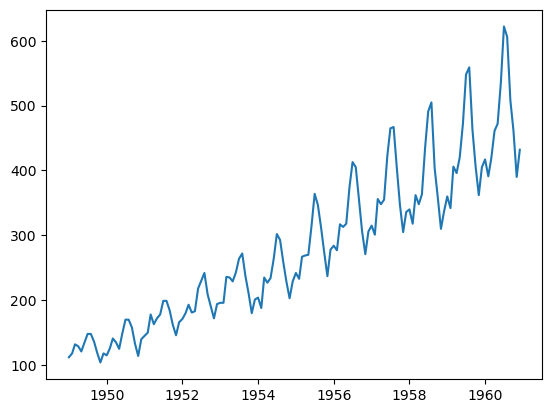

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
plt.plot(df)
plt.show()


In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

df = pd.read_csv(
    url,
    parse_dates=['Month'],
    index_col='Month'
)

# Handle missing values
df = df.ffill()

# Convert to supervised
def series_to_supervised(data, n_in=3):
    df = pd.DataFrame(data)
    cols = []

    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))

    cols.append(df)

    agg = pd.concat(cols, axis=1)
    agg.dropna(inplace=True)

    return agg

supervised = series_to_supervised(df['Passengers'], 3)

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(supervised)

print("Shape:", scaled_data.shape)
print(scaled_data[:5])

Shape: (141, 4)
[[0.01544402 0.02702703 0.05405405 0.04826255]
 [0.02702703 0.05405405 0.04826255 0.03281853]
 [0.05405405 0.04826255 0.03281853 0.05984556]
 [0.04826255 0.03281853 0.05984556 0.08494208]
 [0.03281853 0.05984556 0.08494208 0.08494208]]


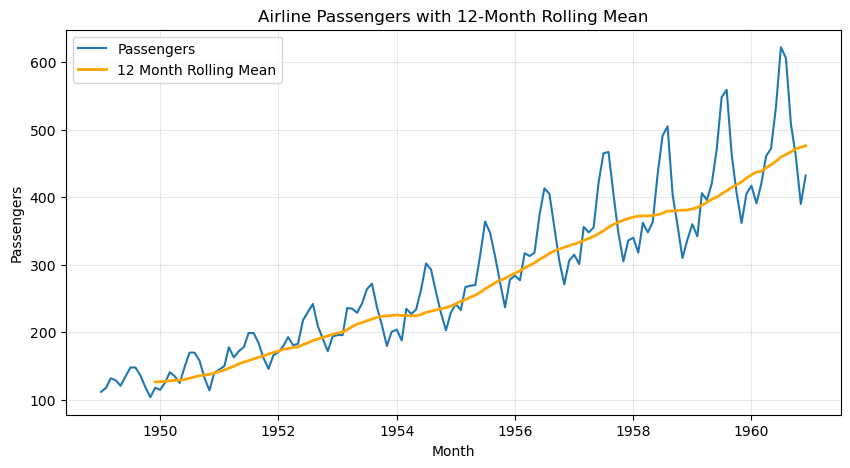

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Calculate 12-month rolling mean
df['12 Month Rolling Mean'] = df['Passengers'].rolling(window=12).mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Passengers')
plt.plot(df.index, df['12 Month Rolling Mean'],
         color='orange',
         linewidth=2,
         label='12 Month Rolling Mean')

plt.title('Airline Passengers with 12-Month Rolling Mean')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

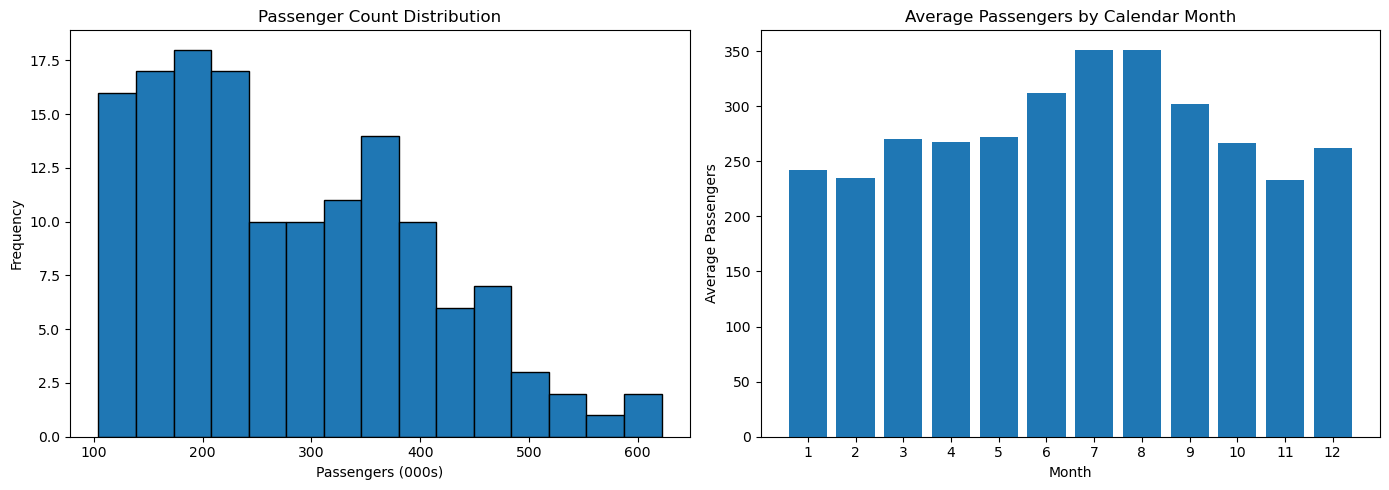

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Extract month number
df['Month_Num'] = df['Month'].dt.month

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------
# Histogram (Distribution)
# --------------------------
axes[0].hist(df['Passengers'], bins=15, edgecolor='black')
axes[0].set_title('Passenger Count Distribution')
axes[0].set_xlabel('Passengers (000s)')
axes[0].set_ylabel('Frequency')

# --------------------------
# Monthly Average Bar Chart
# --------------------------
monthly_avg = df.groupby('Month_Num')['Passengers'].mean()

axes[1].bar(monthly_avg.index, monthly_avg.values)
axes[1].set_title('Average Passengers by Calendar Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Passengers')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)
# Last 24 months
months = df.index[-24:]

plt.figure(figsize=(14, 7))

plt.plot(months, y_test[-24:],
         marker='o',
         linewidth=2,
         label='Actual')

plt.plot(months, y_pred_lr[-24:],
         linewidth=1.8,
         label='Linear Regression')

plt.plot(months, y_pred_xgb[-24:],
         linewidth=1.8,
         label='XGBoost')

plt.plot(months, y_pred_ann[-24:],
         linewidth=1.8,
         label='ANN')

plt.plot(months, y_pred_lstm[-24:],
         linewidth=1.8,
         label='LSTM')

plt.plot(months, y_pred_arima[-24:],
         linewidth=1.8,
         label='ARIMA')

plt.title('Actual vs Predicted Passengers (Last 24 Months)')
plt.xlabel('Month')
plt.ylabel('Passengers (000s)')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1400x700 with 0 Axes>